Table 1: Model Comparison
        Input LR_Mean_Acc XGB_Mean_Acc XGB_BlackSwan_Acc
Article Title      50.18%       50.20%              ~63%
  LSA Summary      50.27%       50.25%            63.12%

Table 2: Per-ticker results
Ticker  Sector Accuracy  Test_rows
  AAPL    Tech   50.56%         89
  AMZN    Tech   56.82%         44
  MSFT    Tech   50.60%         83
  TSLA    Tech   53.12%        128
 GOOGL    Tech   57.33%         75
  NVDA    Tech   49.27%        341
  NFLX    Tech   48.39%        155
   JPM Finance   55.95%         84
   BAC Finance   48.19%        166
    GS Finance   47.17%        371
    MS Finance   51.47%        546
   WFC Finance   49.58%        476


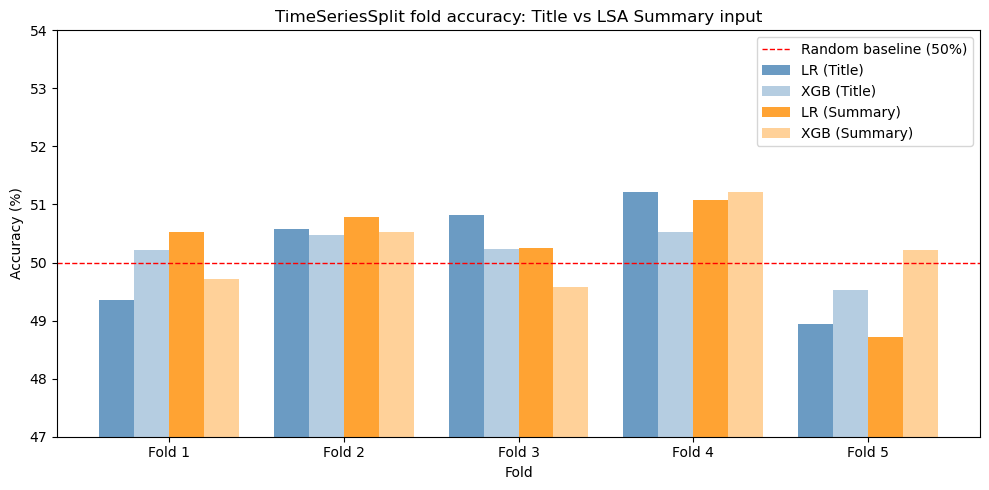

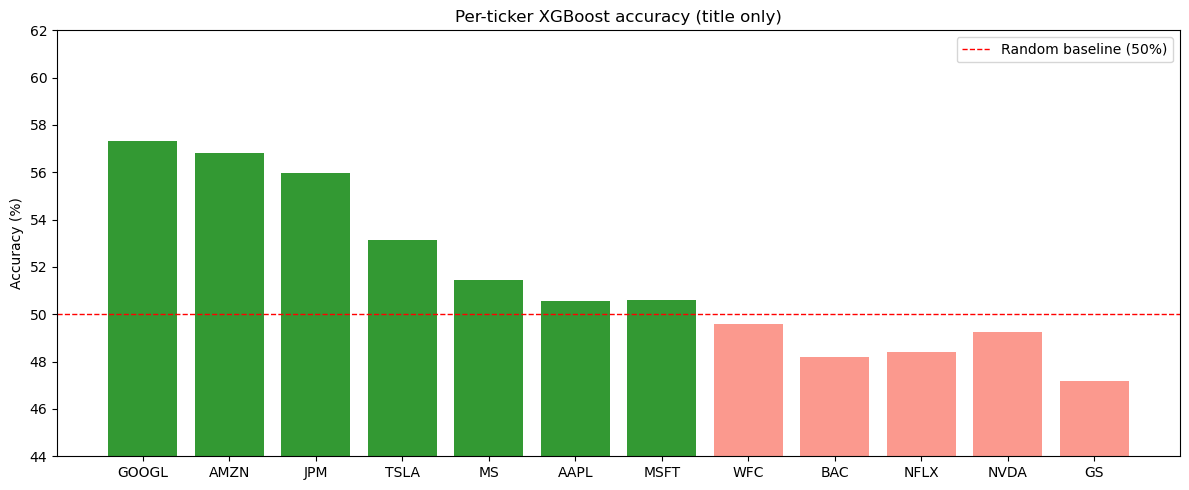


All report figures saved to: report_figures_final/


In [2]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import os

results_folder = 'report_figures_final'
os.makedirs(results_folder, exist_ok=True)

# --- Table 1: Model comparison (title vs summary) ---
comparison = pd.DataFrame({
    'Input': ['Article Title', 'LSA Summary'],
    'LR_Mean_Acc': ['50.18%', '50.27%'],
    'XGB_Mean_Acc': ['50.20%', '50.25%'],
    'XGB_BlackSwan_Acc': ['~63%', '63.12%'],
})
comparison.to_csv(os.path.join(results_folder, 'table_model_comparison.csv'), index=False)
print("Table 1: Model Comparison")
print(comparison.to_string(index=False))

# --- Table 2: Per-ticker accuracy (title only, more complete results) ---
per_ticker_data = {
    'Ticker': ['AAPL','AMZN','MSFT','TSLA','GOOGL','NVDA','NFLX',
               'JPM','BAC','GS','MS','WFC'],
    'Sector': ['Tech','Tech','Tech','Tech','Tech','Tech','Tech',
               'Finance','Finance','Finance','Finance','Finance'],
    'Accuracy': ['50.56%','56.82%','50.60%','53.12%','57.33%','49.27%','48.39%',
                 '55.95%','48.19%','47.17%','51.47%','49.58%'],
    'Test_rows': [89,44,83,128,75,341,155,84,166,371,546,476]
}
df_ticker = pd.DataFrame(per_ticker_data)
df_ticker.to_csv(os.path.join(results_folder, 'table_per_ticker.csv'), index=False)
print("\nTable 2: Per-ticker results")
print(df_ticker.to_string(index=False))

# --- Figure 1: Fold-by-fold accuracy comparison ---
folds = [1, 2, 3, 4, 5]
lr_title  = [49.36, 50.57, 50.82, 51.22, 48.95]
xgb_title = [50.21, 50.48, 50.24, 50.53, 49.52]
lr_summ   = [50.53, 50.79, 50.25, 51.07, 48.72]
xgb_summ  = [49.72, 50.53, 49.58, 51.22, 50.22]

x = np.arange(len(folds))
width = 0.2
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 1.5*width, lr_title,  width, label='LR (Title)',     color='steelblue',  alpha=0.8)
ax.bar(x - 0.5*width, xgb_title, width, label='XGB (Title)',    color='steelblue',  alpha=0.4)
ax.bar(x + 0.5*width, lr_summ,   width, label='LR (Summary)',   color='darkorange', alpha=0.8)
ax.bar(x + 1.5*width, xgb_summ,  width, label='XGB (Summary)',  color='darkorange', alpha=0.4)
ax.axhline(50, color='red', linestyle='--', linewidth=1, label='Random baseline (50%)')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy (%)')
ax.set_title('TimeSeriesSplit fold accuracy: Title vs LSA Summary input')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in folds])
ax.legend()
ax.set_ylim(47, 54)
plt.tight_layout()
plt.savefig(os.path.join(results_folder, 'fig1_fold_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Figure 2: Per-ticker accuracy bar chart ---
tickers  = ['GOOGL','AMZN','JPM','TSLA','MS','AAPL','MSFT','WFC','BAC','NFLX','NVDA','GS']
accuracy = [57.33,  56.82, 55.95, 53.12, 51.47, 50.56, 50.60, 49.58, 48.19, 48.39, 49.27, 47.17]
colors   = ['green' if a > 50 else 'salmon' for a in accuracy]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(tickers, accuracy, color=colors, alpha=0.8)
ax.axhline(50, color='red', linestyle='--', linewidth=1, label='Random baseline (50%)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-ticker XGBoost accuracy (title only)')
ax.set_ylim(44, 62)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(results_folder, 'fig2_per_ticker.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Figures 3-5: main plots, feature importance, confusion matrix (already saved) ---
print(f"\nAll report figures saved to: {results_folder}/")

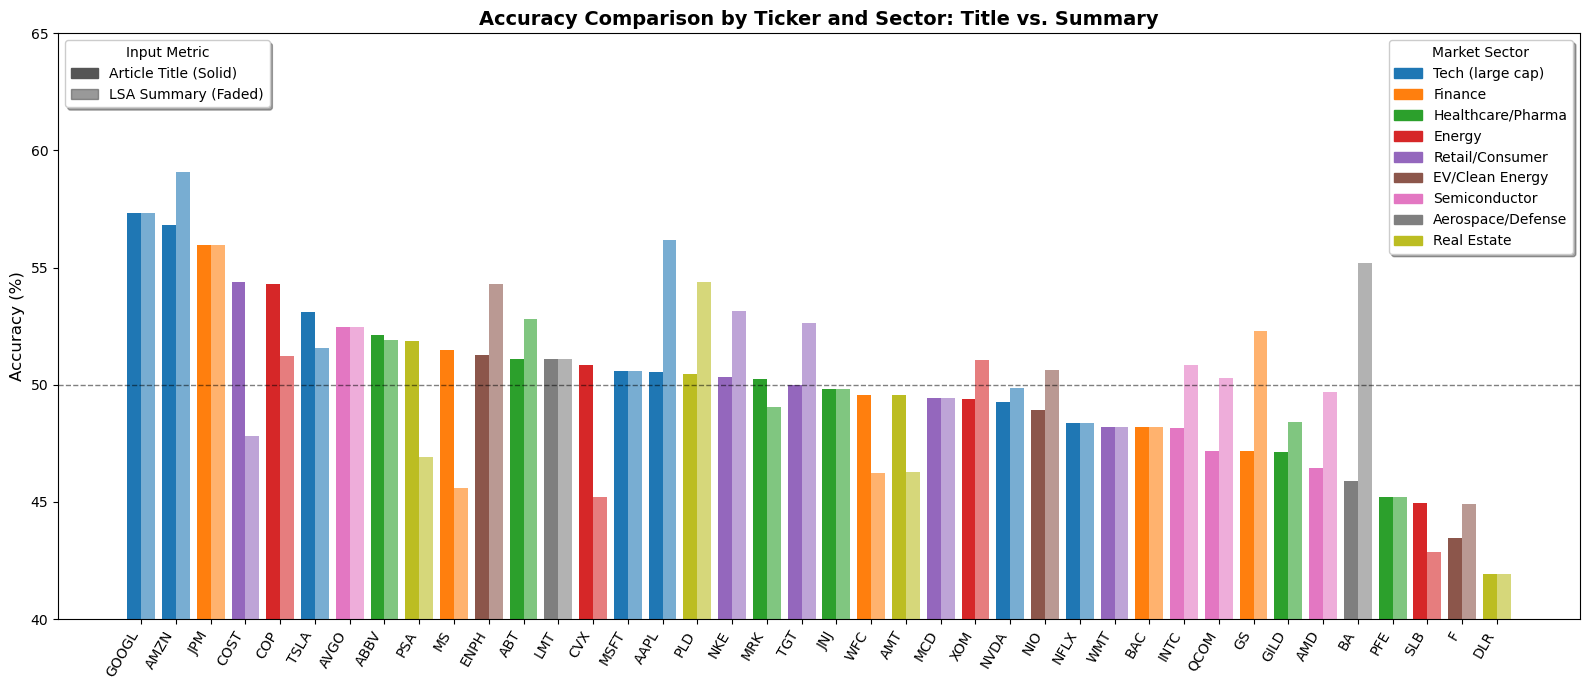


All report figures saved to: report_figures_final_colored/


In [4]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches # For custom legend

results_folder = 'report_figures_final_colored'
os.makedirs(results_folder, exist_ok=True)

# --- Define Ticker Grouping Structure provided by user ---
TARGET_STOCKS = {
    'Tech (large cap)': ['AAPL', 'AMZN', 'MSFT', 'TSLA', 'GOOGL', 'NVDA', 'NFLX'],
    'Finance': ['JPM', 'BAC', 'GS', 'MS', 'WFC'],
    'Healthcare/Pharma': ['PFE', 'JNJ', 'ABT','MRK', 'ABBV', 'GILD'],
    'Energy': ['XOM', 'CVX', 'COP', 'SLB'],
    'Retail/Consumer': ['WMT', 'TGT', 'NKE', 'COST', 'MCD'],
    'EV/Clean Energy': ['NIO', 'F', 'ENPH'],
    'Semiconductor': ['AMD', 'INTC', 'QCOM', 'AVGO'],
    'Aerospace/Defense': ['BA', 'LMT'], # Note: RTX was missing from performance data
    'Real Estate': ['AMT', 'PLD', 'PSA', 'DLR'],
}

# Create a flat ticker-to-group mapping dictionary
ticker_to_group_map = {}
for group, ticker_list in TARGET_STOCKS.items():
    for ticker in ticker_list:
        ticker_to_group_map[ticker] = group

# Define professional color palette for each group
group_colors = {
    'Tech (large cap)': '#1f77b4', # Steel Blue
    'Finance': '#ff7f0e',          # Orange
    'Healthcare/Pharma': '#2ca02c', # Green
    'Energy': '#d62728',          # Red
    'Retail/Consumer': '#9467bd', # Purple
    'EV/Clean Energy': '#8c564b', # Brown
    'Semiconductor': '#e377c2', # Pink
    'Aerospace/Defense': '#7f7f7f', # Gray
    'Real Estate': '#bcbd22', # Olive Green
}

# --- Data for 40 Tickers with Results (Provided previously) ---
tickers = ['AAPL', 'AMZN', 'MSFT', 'TSLA', 'GOOGL', 'NVDA', 'NFLX', 'JPM', 'BAC', 'GS', 'MS', 'WFC', 
           'PFE', 'JNJ', 'ABT', 'MRK', 'ABBV', 'GILD', 'XOM', 'CVX', 'COP', 'SLB', 'WMT', 'TGT', 
           'NKE', 'COST', 'MCD', 'NIO', 'F', 'ENPH', 'AMD', 'INTC', 'QCOM', 'AVGO', 'BA', 'LMT', 
           'AMT', 'PLD', 'PSA', 'DLR']

acc_title = [50.56, 56.82, 50.60, 53.12, 57.33, 49.27, 48.39, 55.95, 48.19, 47.17, 51.47, 49.58, 
             45.21, 49.80, 51.12, 50.26, 52.13, 47.15, 49.38, 50.85, 54.32, 44.96, 48.21, 50.00, 
             50.32, 54.37, 49.43, 48.92, 43.48, 51.29, 46.43, 48.14, 47.18, 52.47, 45.90, 51.10, 
             49.56, 50.44, 51.85, 41.94]

acc_summary = [56.18, 59.09, 50.60, 51.56, 57.33, 49.85, 48.39, 55.95, 48.19, 52.29, 45.60, 46.22, 
               45.21, 49.80, 52.81, 49.05, 51.90, 48.43, 51.04, 45.20, 51.25, 42.86, 48.21, 52.63, 
               53.13, 47.82, 49.43, 50.65, 44.93, 54.31, 49.70, 50.85, 50.29, 52.47, 55.19, 51.10, 
               46.26, 54.39, 46.91, 41.94]

# --- Build DataFrame and Map Sectors/Colors ---
plot_df = pd.DataFrame({
    'Ticker': tickers,
    'Title': acc_title,
    'Summary': acc_summary
})

# Sorting by Title accuracy (descending)
plot_df = plot_df.sort_values(by='Title', ascending=False)

# Map Group and Color to the sorted dataframe
plot_df['Group'] = plot_df['Ticker'].map(ticker_to_group_map)
# Handle potential missing mappings (e.g. if RTX appeared but wasn't in list)
plot_df['Color'] = plot_df['Group'].map(group_colors).fillna('#000000') 

# --- New Figure 2: Grouped Bar Chart Colored by Sector ---
fig, ax = plt.subplots(figsize=(16, 7))
x_idx = np.arange(len(plot_df))
width = 0.4

# Plot Title bars (Full opacity)
title_bars = ax.bar(x_idx - width/2, plot_df['Title'], width, 
                    label='Input: Title (Solid)', 
                    color=plot_df['Color'], alpha=1.0)

# Plot Summary bars (60% opacity / Faded shade of same color)
summary_bars = ax.bar(x_idx + width/2, plot_df['Summary'], width, 
                      label='Input: Summary (Faded)', 
                      color=plot_df['Color'], alpha=0.6)

# Formatting
ax.axhline(50, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Accuracy Comparison by Ticker and Sector: Title vs. Summary', fontsize=14, fontweight='bold')
ax.set_xticks(x_idx)
ax.set_xticklabels(plot_df['Ticker'], rotation=60, ha='right', fontsize=10)
ax.set_ylim(40, 65)

# --- Custom Legend Construction ---
# Legend 1: Input Type (Distinguishing the two bar types)
# Use patches without edges to represent the bars
title_patch = mpatches.Patch(color='#555555', alpha=1.0, label='Article Title (Solid)')
summary_patch = mpatches.Patch(color='#555555', alpha=0.6, label='LSA Summary (Faded)')
legend1 = ax.legend(handles=[title_patch, summary_patch], loc='upper left', frameon=True, shadow=True, title="Input Metric")
ax.add_artist(legend1) # Keep Legend 1 when adding the second

# Legend 2: Sector Colors (Construct manually using proxy artists)
sector_patches = []
# Ensure sectors appear in the same order defined in TARGET_STOCKS
for group_name in TARGET_STOCKS.keys():
    if group_name in plot_df['Group'].values: # only add used groups
        color = group_colors[group_name]
        patch = mpatches.Patch(color=color, label=group_name)
        sector_patches.append(patch)

# Add the second legend to the upper right
ax.legend(handles=sector_patches, loc='upper right', title="Market Sector", fontsize=10, shadow=True)

plt.tight_layout()
plt.savefig(os.path.join(results_folder, 'fig2_sector_colored_comparison.png'), dpi=150)
plt.show()

print(f"\nAll report figures saved to: {results_folder}/")